In [81]:
import math
import random
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Question 1

In [82]:
# bringing over data

scores = [65, 70, 68, 73, 75, 80, 85, 78, 90, 100]

In [83]:
# part a

# create variables
n = len(scores)
t = 2.262  # critical value given

# calculate sample mean
x_bar = sum(scores) / n

# calculate sample standard deviation
sum_squared_diff = sum((x - x_bar) ** 2 for x in scores)
s = math.sqrt(sum_squared_diff / (n - 1))

# calculate margin of error
r = s / math.sqrt(n) * t

# confidence interval
ci_lower = x_bar - r
ci_upper = x_bar + r

print(f"Sample mean (x̄): {x_bar}")
print(f"Sample standard deviation (s): {s}")
print()
print(f"Margin of error (r): {r}")
print(f"95% Confidence Interval: [{ci_lower}, {ci_upper}]")

Sample mean (x̄): 78.4
Sample standard deviation (s): 10.782702196883056

Margin of error (r): 7.7129445894547946
95% Confidence Interval: [70.68705541054521, 86.1129445894548]


In [84]:
# part b

# function to create bootstrap samples
def bootstrap_sample(data, n_samples=40):
    bootstrap_means = []
    for i in range(n_samples):
        # create a bootstrap sample by sampling with replacement
        sample = random.choices(data, k=len(data))
        # calculate mean of this bootstrap sample
        sample_mean = sum(sample) / len(sample)
        bootstrap_means.append(sample_mean)
    return bootstrap_means

# create 40 bootstrapped samples and calculate the means
bootstrap_means = bootstrap_sample(scores, 40)

# sort the bootstrap means
sorted_means = sorted(bootstrap_means)

# calculate 95% confidence interval
lower_index = int(0.025 * len(sorted_means)) 
upper_index = int(0.975 * len(sorted_means)) 

ci_lower = sorted_means[lower_index]
ci_upper = sorted_means[upper_index]

# print results
print("Original sample mean:", sum(scores) / n)
print("Bootstrap means:", bootstrap_means)
print()
print("95% Confidence Interval from bootstrap:")
print(f"Interval: [{ci_lower}, {ci_upper}]")

Original sample mean: 78.4
Bootstrap means: [79.4, 81.4, 79.4, 76.7, 82.7, 71.5, 73.0, 75.3, 81.6, 84.1, 78.2, 79.0, 80.9, 79.1, 81.4, 76.6, 75.9, 78.1, 81.4, 78.2, 83.0, 79.9, 76.8, 76.6, 76.4, 75.4, 79.5, 79.4, 78.8, 83.1, 78.3, 75.2, 81.4, 73.8, 78.6, 79.2, 74.7, 85.8, 79.1, 88.3]

95% Confidence Interval from bootstrap:
Interval: [73.0, 88.3]


## part c

I would use the t-distribution method over bootstrapping because the t-distribution is better for datasets with small sample sizes. It accounts for error stemming from having a small dataset by having larger tails than z-distributions. Bootstrapping with 40 resamples from a small dataset is not as reliable because the bootstrap resample distributions may not accurately represent the popultaion data and extreme values can significantly effect the results. This can also be seen by the confidence interval varying greatly when rerunning the bootstrapping method code. 

# Question 2

In [85]:
# part a

# we are using the same data as question 1

# shuffle randomly
shuffled_scores = scores.copy()
random.shuffle(shuffled_scores)

# split into 5 subsets of 2 scores 
subsets = []
for i in range(0, len(shuffled_scores), 2):
    subset = shuffled_scores[i:i+2]
    subsets.append(subset)

# print results
print("5 subsets:")
for i, subset in enumerate(subsets, 1):
    print(f"Subset {i}: {subset}")

5 subsets:
Subset 1: [85, 73]
Subset 2: [68, 75]
Subset 3: [78, 70]
Subset 4: [90, 65]
Subset 5: [80, 100]


In [86]:
# part b

# sets were made in part a

# create a place to store the training means
training_means = []

# create training set
for i, validation_set in enumerate(subsets, 1):
    training_set = [score for score in scores if score not in validation_set]
    
    # calculate mean of training set
    training_mean = sum(training_set)/8
    training_means.append(training_mean)
    
    print(f"Fold {i}:")
    print(f"Validation set: {validation_set}")
    print(f"Training set: {training_set}")
    print(f"Training set mean: {training_mean}")
    print()

Fold 1:
Validation set: [85, 73]
Training set: [65, 70, 68, 75, 80, 78, 90, 100]
Training set mean: 78.25

Fold 2:
Validation set: [68, 75]
Training set: [65, 70, 73, 80, 85, 78, 90, 100]
Training set mean: 80.125

Fold 3:
Validation set: [78, 70]
Training set: [65, 68, 73, 75, 80, 85, 90, 100]
Training set mean: 79.5

Fold 4:
Validation set: [90, 65]
Training set: [70, 68, 73, 75, 80, 85, 78, 100]
Training set mean: 78.625

Fold 5:
Validation set: [80, 100]
Training set: [65, 70, 68, 73, 75, 85, 78, 90]
Training set mean: 75.5



In [87]:
# part c

# creating place to store the error values
error_values = []

# pair correct data and calculate absolute error
for i in range(5):
    validation_set = subsets[i]
    prediction = training_means[i]
    absolute_errors = [abs(score - prediction) for score in validation_set]
    
    # calculate mean absolute error
    mae = sum(absolute_errors) / 2
    error_values.append(mae)

print (f"Absolute errors: {error_values}")

Absolute errors: [6.0, 8.625, 5.5, 12.5, 14.5]


In [88]:
# part d

# calculate overall mean absolute error
overall_mae = sum(error_values) / len(error_values)
print(f"Mean Absolute Error: {overall_mae}")

Mean Absolute Error: 9.425


In [89]:
# part e

# calculate score mean
score_mean = sum(scores) / 10

# calculate absolute errors using overall mean as prediction
absolute_errors = [abs(score - score_mean) for score in scores]

# calculate mean absolute error
mae = sum(absolute_errors) / len(absolute_errors)

print(f"Overall mean: {score_mean}")
print(f"Mean Absolute Error: {mae}")

Overall mean: 78.4
Mean Absolute Error: 8.280000000000001


# Question 3

In [90]:
# import data

from ISLP import load_data
OJ = load_data('OJ')
OJ

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.00,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.30,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.00,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.00,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.00,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065,CH,252,7,1.86,2.09,0.10,0.00,0,0,0.587822,2.09,1.76,0.33,Yes,0.000000,0.053763,0.23,0
1066,CH,256,7,1.86,2.18,0.00,0.00,0,0,0.670258,2.18,1.86,0.32,Yes,0.000000,0.000000,0.32,0
1067,MM,257,7,1.86,2.18,0.00,0.00,0,0,0.736206,2.18,1.86,0.32,Yes,0.000000,0.000000,0.32,0
1068,CH,261,7,1.86,2.13,0.00,0.24,0,0,0.588965,1.89,1.86,0.03,Yes,0.112676,0.000000,0.27,0


In [91]:
# part a

# convert Store7 to numeric
OJ['Store7'] = OJ['Store7'].map({'Yes': 1, 'No': 0})

# create training set with 800 random observations
train_data = OJ.sample(n=800, random_state=42)

# create test set with remaining observations
test_data = OJ.drop(train_data.index)

In [92]:
# part b

# prepare training data
X_train = train_data.drop('Purchase', axis=1)
y_train = train_data['Purchase']

# fit tree with max 6 leaf nodes
tree_clf = DecisionTreeClassifier(max_leaf_nodes=6, random_state=42)
tree_clf.fit(X_train, y_train)

# predictions on training data
y_train_pred = tree_clf.predict(X_train)

# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
print("Confusion Matrix (Training Data):")
print(cm)

# calculate misclassification error
accuracy = accuracy_score(y_train, y_train_pred)
misclassification_error = 1 - accuracy

print(f"Misclassification Error: {misclassification_error}")

Confusion Matrix (Training Data):
[[394 100]
 [ 41 265]]
Misclassification Error: 0.17625000000000002


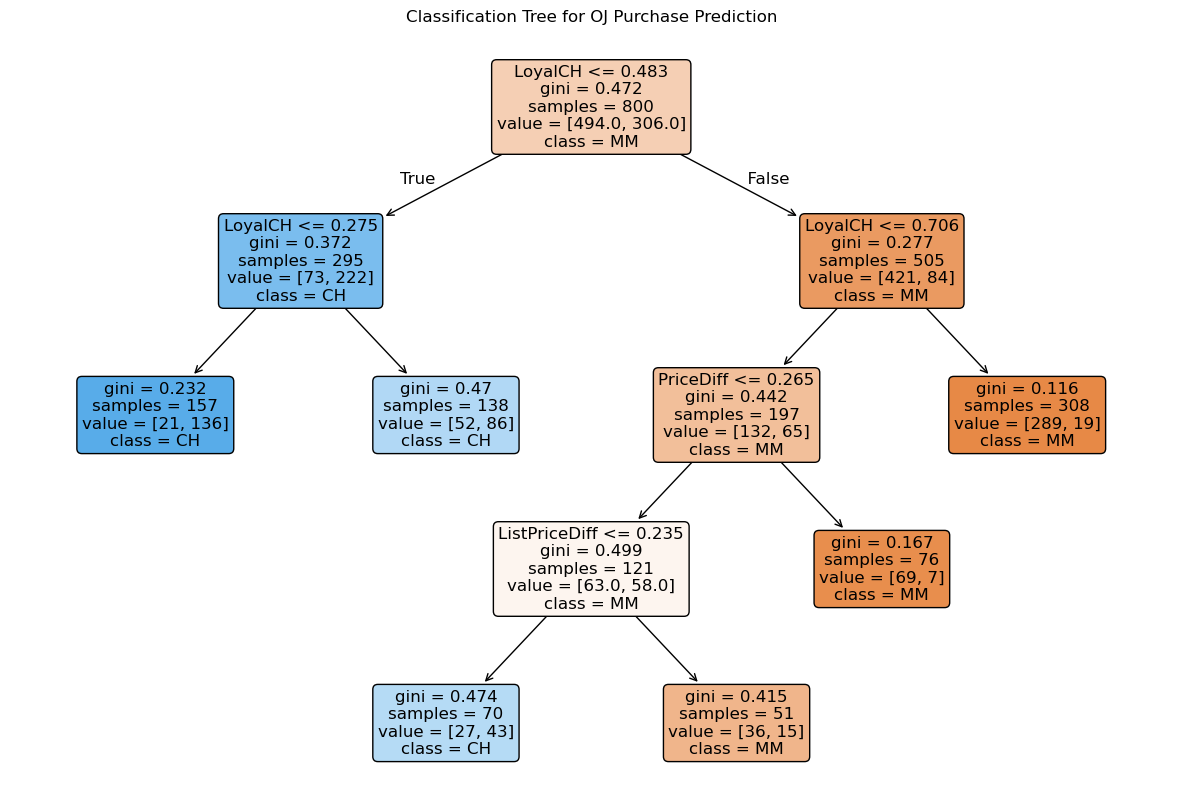

Feature Importance:
           feature  importance
8          LoyalCH    0.884782
11       PriceDiff    0.080455
15   ListPriceDiff    0.034763
9      SalePriceMM    0.000000
14       PctDiscCH    0.000000
13       PctDiscMM    0.000000
12          Store7    0.000000
10     SalePriceCH    0.000000
0   WeekofPurchase    0.000000
1          StoreID    0.000000
7        SpecialMM    0.000000
6        SpecialCH    0.000000
5           DiscMM    0.000000
4           DiscCH    0.000000
3          PriceMM    0.000000
2          PriceCH    0.000000
16           STORE    0.000000


In [93]:
# part c

# create plot of the tree
plt.figure(figsize=(15, 10))
plot_tree(tree_clf, 
          feature_names=X_train.columns,
          class_names=['MM', 'CH'], 
          filled=True,
          rounded=True,
          fontsize=12)

plt.title("Classification Tree for OJ Purchase Prediction")
plt.show()

# interpret results
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': tree_clf.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

In [94]:
# part d

# prepare test data
X_test = test_data.drop('Purchase', axis=1)
y_test = test_data['Purchase']

# predict on test data
y_test_pred = tree_clf.predict(X_test)

# confusion matrix for test data
cm_test = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix (Test Data):")
print(cm_test)

# calculate misclassification error on test data
accuracy_test = accuracy_score(y_test, y_test_pred)
misclassification_error_test = 1 - accuracy_test

print(f"Test Misclassification Error: {misclassification_error_test}")

Confusion Matrix (Test Data):
[[128  31]
 [ 14  97]]
Test Misclassification Error: 0.16666666666666663


In [95]:
# part e

# fit new tree with max 8 leaf nodes
tree_clf_8 = DecisionTreeClassifier(max_leaf_nodes=8, random_state=42)
tree_clf_8.fit(X_train, y_train)

# calculate test error
y_test_pred_8 = tree_clf_8.predict(X_test)
accuracy_test_8 = accuracy_score(y_test, y_test_pred_8)
misclassification_error_test_8 = 1 - accuracy_test_8

print(f"Test Error (6 leaves): {misclassification_error_test}")
print(f"Test Error (8 leaves): {misclassification_error_test_8}")
print(f"Change in test error: {misclassification_error_test_8 - misclassification_error_test}")

Test Error (6 leaves): 0.16666666666666663
Test Error (8 leaves): 0.14814814814814814
Change in test error: -0.01851851851851849


## part e

The test error decreased from 16.67% to 14.81% which is an improvement of 1.85 percentage points. This means that the tree with 8 leaf nodes performs better on unseen data than the tree with 6 leaf nodes.

In [96]:
# part f

# calculate misclassification error on test data
accuracy_test = accuracy_score(y_test, y_test_pred_8)
misclassification_error_test_8 = 1 - accuracy_test_8

print(f"Test Error: {misclassification_error_test_8}")

Test Error: 0.14814814814814814


## part f

The model in part e is not overfit because the test error is lower than the training error, which shows that the model is not overfit. If the model was overfit, the test error would show be higher than the training error because the model would be overrelying on the test data values instead of learning the patterns in order to predict values more accurately.

In [97]:
# part g

# test different numbers of leaf nodes
leaf_nodes_range = range(2, 20)
cv_scores = []

for n_leaf in leaf_nodes_range:
    tree = DecisionTreeClassifier(max_leaf_nodes=n_leaf, random_state=42)
    scores = cross_val_score(tree, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# find optimal number of leaf nodes
optimal_leaf_nodes = leaf_nodes_range[np.argmax(cv_scores)]
best_cv_score = max(cv_scores)

print(f"Optimal number of leaf nodes: {optimal_leaf_nodes}")
print(f"Best cross-validation accuracy: {best_cv_score}")

# train model with optimal leaf nodes
optimal_tree = DecisionTreeClassifier(max_leaf_nodes=optimal_leaf_nodes, random_state=42)
optimal_tree.fit(X_train, y_train)

# test error 
y_test_optimal = optimal_tree.predict(X_test)
test_accuracy_optimal = accuracy_score(y_test, y_test_optimal)
test_error_optimal = 1 - test_accuracy_optimal

print(f"\nTest error with optimal model: {test_error_optimal}")
print(f"Test error for 8 leaf model: {misclassification_error_test_8}")
print(f"Improvement: {test_error_optimal - misclassification_error_test_8}")

Optimal number of leaf nodes: 11
Best cross-validation accuracy: 0.80625

Test error with optimal model: 0.16666666666666663
Test error for 8 leaf model: 0.14814814814814814
Improvement: 0.01851851851851849


In [98]:
# part h

# create random forest model
rf_model = RandomForestClassifier(
    n_estimators=100,   
    max_features='sqrt', 
    random_state=42
)

# fit the model
rf_model.fit(X_train, y_train)

# predictions on test data
y_test_rf = rf_model.predict(X_test)

# misclassification rate
test_accuracy_rf = accuracy_score(y_test, y_test_rf)
test_error_rf = 1 - test_accuracy_rf

print("Initial Hyperparameters")
print(f"n_estimators: {rf_model.n_estimators}")
print(f"max_features: {rf_model.max_features}")
print(f"random_state: {rf_model.random_state}")


# compare with single tree
print(f"Total misclassification rate: {test_error_rf}")

Initial Hyperparameters
n_estimators: 100
max_features: sqrt
random_state: 42
Total misclassification rate: 0.18888888888888888


In [99]:
# part i

# define smaller parameter grid
param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

# create and fit randomized search
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=4,
    cv=3,
    scoring='accuracy',
    random_state=42
)

random_search.fit(X_train, y_train)

# get best parameters
best_params = random_search.best_params_
best_rf_model = random_search.best_estimator_

# test predictions with optimized model
y_test_best_rf = best_rf_model.predict(X_test)
test_accuracy_best_rf = accuracy_score(y_test, y_test_best_rf)
test_error_best_rf = 1 - test_accuracy_best_rf

print("Final Hyperparameters:")
for param, value in best_params.items():
    print(f"{param}: {value}")

print(f"Total Misclassification Rate: {test_error_best_rf}")

Final Hyperparameters:
n_estimators: 100
min_samples_split: 5
max_features: sqrt
max_depth: 10
Total Misclassification Rate: 0.18518518518518523


In [100]:
# part j

# create a lift chart for final random forest model
def plot_regression_lift_chart(y_true, y_preds, n_bins=10):

    # Create a DataFrame with true values and predicted values
    data = pd.DataFrame({'y_true': y_true, 'y_preds': y_preds})
    
    # Sort the DataFrame by predicted values
    data = data.sort_values(by='y_preds', ascending=False)

    # Create bins based on predicted values
    data['bin'] = pd.qcut(data['y_preds'], n_bins, labels=False, duplicates='drop')

    # Calculate lift
    lift_data = data.groupby('bin').agg(
        total_count=('y_true', 'count'),
        actual_mean=('y_true', 'mean'),
        predicted_mean=('y_preds', 'mean')
    ).reset_index()

    # Calculate expected mean (mean of actual values)
    expected_mean = data['y_true'].mean()
    
    # Calculate lift
    lift_data['lift'] = lift_data['actual_mean'] / expected_mean

    # Plot the lift chart
    plt.figure(figsize=(10, 6))
    plt.plot(lift_data['bin'], lift_data['lift'], marker='o', label='Lift')
    plt.axhline(y=1, color='r', linestyle='--', label='Random Guessing Lift (1)')
    plt.title('Lift Chart for Regression Model')
    plt.xlabel('Bins')
    plt.ylabel('Lift')
    plt.xticks(lift_data['bin'])
    plt.legend()
    plt.grid()
    plt.show()

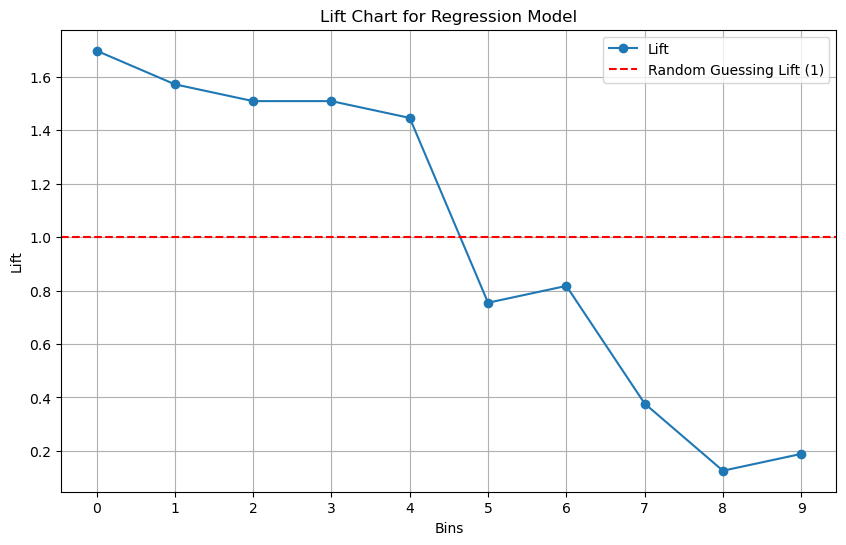

In [101]:
# convert true labels to binary (CH = 1, MM = 0)
y_true_binary = (y_test == 'CH').astype(int)

# use predicted probabilities for CH class
y_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]  # probability of CH

# call function
plot_regression_lift_chart(y_true_binary, y_pred_proba, n_bins=10)

## part j

The model successfully identifies the amounts of customers that are likely and unlikey to buy Citrus Hill juice. Customers in the top group are around 1.7 times more likely to buy Citrus Hill than average, and the customers in the bottom group are a lot less likely to purchase Citrus Hill juice.

In [102]:
# part k

# fill NaN values with 0
X_train_filled = X_train.fillna(0)
X_test_filled = X_test.fillna(0)

# create gradient boosting model with initial hyperparameters
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# fit the model
gb_model.fit(X_train_filled, y_train)

# predictions on test data
y_test_gb = gb_model.predict(X_test_filled)

# misclassification rate
test_accuracy_gb = accuracy_score(y_test, y_test_gb)
test_error_gb = 1 - test_accuracy_gb

print("Initial Hyperparameters:")
print(f"n_estimators: {gb_model.n_estimators}")
print(f"learning_rate: {gb_model.learning_rate}")
print(f"max_depth: {gb_model.max_depth}")
print(f"random_state: {gb_model.random_state}")

print(f"Total Misclassification Rate: {test_error_gb}")

Initial Hyperparameters:
n_estimators: 100
learning_rate: 0.1
max_depth: 3
random_state: 42
Total Misclassification Rate: 0.1703703703703704


In [103]:
# part l

# define parameter distribution for gradient boosting
param_dist = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5]
}

# create and fit randomized search
gb_random_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42
)

gb_random_search.fit(X_train_filled, y_train)

# get best parameters and model
best_gb_params = gb_random_search.best_params_
best_gb_model = gb_random_search.best_estimator_

# predictions with optimized model
y_test_best_gb = best_gb_model.predict(X_test_filled)
test_accuracy_best_gb = accuracy_score(y_test, y_test_best_gb)
test_error_best_gb = 1 - test_accuracy_best_gb

print("Final Hyperparameters:")
for param, value in best_gb_params.items():
    print(f"{param}: {value}")

print(f"Total Misclassification Rate: {test_error_best_gb}")

Final Hyperparameters:
n_estimators: 50
min_samples_split: 5
max_depth: 2
learning_rate: 0.05
Total Misclassification Rate: 0.14814814814814814


In [104]:
# part m

# create a double lift chart 
def plot_double_lift_chart(y_true, y_pred_model1, y_pred_model2,
                           model1_name='Model A', model2_name='Model B',
                           n_bins=10):

    # Build combined dataframe
    data = pd.DataFrame({
        'y_true': y_true,
        'pred1': y_pred_model1,
        'pred2': y_pred_model2
    })

    # Avoid division by zero
    data = data[data['pred2'] != 0]

    # Compute ratio of predictions
    data['ratio'] = data['pred1'] / data['pred2']

    # Sort descending by ratio
    data = data.sort_values(by='ratio', ascending=False)

    # Create quantile bins based on the ratio
    data['bin'] = pd.qcut(data['ratio'], n_bins, labels=False, duplicates='drop')

    # Overall means for normalization
    overall_mean_true = data['y_true'].mean()
    overall_mean_pred1 = data['pred1'].mean()
    overall_mean_pred2 = data['pred2'].mean()

    # Aggregate lift stats for each bin
    lift_data = data.groupby('bin').agg(
        actual_mean=('y_true', 'mean'),
        model1_mean=('pred1', 'mean'),
        model2_mean=('pred2', 'mean')
    ).reset_index()

    # Compute model error in each bin
    lift_data['model1_lift'] = lift_data['model1_mean'] / lift_data['actual_mean']
    lift_data['model2_lift'] = lift_data['model2_mean'] / lift_data['actual_mean']

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(lift_data['bin'], lift_data['model1_lift'], marker='s', linestyle='-', linewidth=2, label=f'{model1_name} Predicted Lift')
    plt.plot(lift_data['bin'], lift_data['model2_lift'], marker='^', linestyle='--', linewidth=2, label=f'{model2_name} Predicted Lift')

    plt.axhline(y=1, color='red', linestyle=':', label='Baseline (Lift = 1)')
    plt.title(f'Double Lift Chart by Ratio of {model1_name} / {model2_name}', fontsize=14)
    plt.xlabel(f'Bins (sorted by {model1_name} / {model2_name} ratio)')
    plt.ylabel('Lift (Mean / Overall Mean)')
    plt.xticks(np.arange(0, lift_data.shape[0]))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

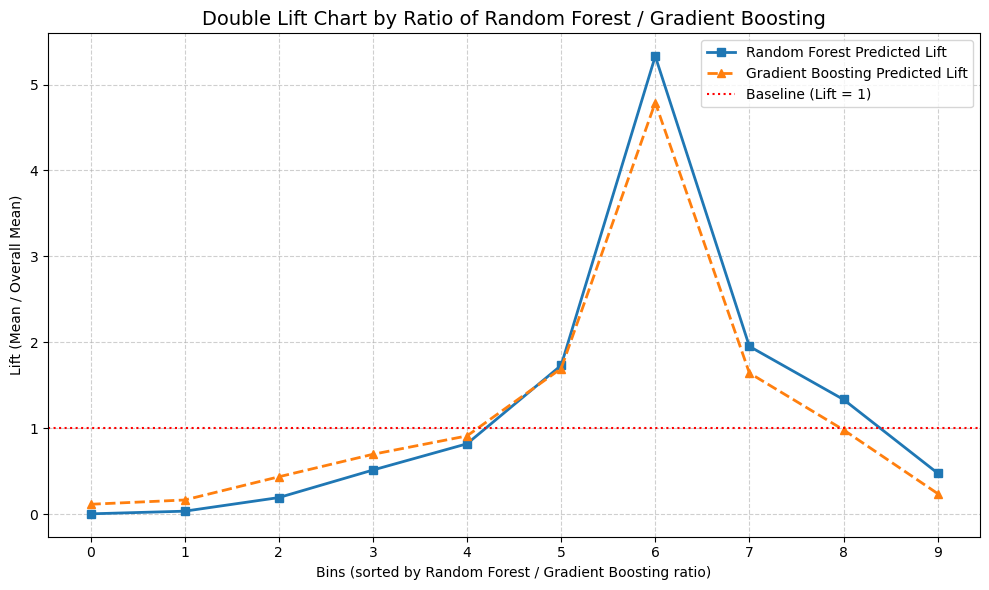

In [105]:
# Get predicted probabilities for both models
y_pred_rf = best_rf_model.predict_proba(X_test_filled)[:, 1]  # Random Forest CH probabilities
y_pred_gb = best_gb_model.predict_proba(X_test_filled)[:, 1]  # Gradient Boosting CH probabilities

# Convert true labels to binary
y_true_binary = (y_test == 'CH').astype(int)

# Create double lift chart
plot_double_lift_chart(
    y_true=y_true_binary,
    y_pred_model1=y_pred_rf,
    y_pred_model2=y_pred_gb,
    model1_name='Random Forest',
    model2_name='Gradient Boosting',
    n_bins=10
)

## part m

Based on the double lift chart, the gradient boosting demonstrates better data segmentation than the random forest. The gradient boosting curve is flatter, which means that it has lower error rates.